# PINN for Cancer Signaling: Temporal Extrapolation Demo

This notebook demonstrates how to:
1. Train a PINN on early time points [0,1,4,8]hrs
2. Extrapolate to late time points [24,48]hrs
3. Visualize training fit and extrapolation performance

**Drug Combination**: Vemurafenib (0.5) + Trametinib (0.3)

In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from train_pinn import train_pinn
from visualize_extrapolation import (
    plot_extrapolation_results, 
    plot_training_history, 
    generate_prediction_table,
    load_pinn_with_data
)
from data_utils import TRAINING_DATA_RAW, SPECIES_ORDER
import os

%matplotlib inline

## Step 1: Configure Training Parameters

The model will train on 4 early time points and predict 2 late time points.

In [2]:
config = {
    'num_epochs': 10000,
    'learning_rate': 0.001,
    'lr_decay': 0.95,
    'batch_size': 4,  # 4 training time points
    'hidden_size': 100,
    'num_physics_points': 100,
    'weight_decay': 1e-5,
    'weights': {
        'data': 1.0,
        'physics': 0.5,
        'boundary': 0.3,
        'conservation': 0.2
    }
}

print("Training Configuration:")
print(f"  Training on: [0, 1, 4, 8] hours")
print(f"  Testing on: [24, 48] hours")
print(f"  Epochs: {config['num_epochs']}")
print(f"  Physics weight: {config['weights']['physics']}")

Training Configuration:
  Training on: [0, 1, 4, 8] hours
  Testing on: [24, 48] hours
  Epochs: 10000
  Physics weight: 0.5


## Step 2: Train the Model

This will take several minutes. The progress bar shows both train and test loss.

In [3]:
# Only run if you want to train from scratch
# Otherwise, skip to the next cell to load a pre-trained model

print("="*60)
print("TRAINING: Vem+Tram at [0,1,4,8]hrs")
print("TESTING: Extrapolating to [24,48]hrs")
print("="*60)

model, k_params, history, scalers, train_data, test_data = train_pinn(config)

TRAINING: Vem+Tram at [0,1,4,8]hrs
TESTING: Extrapolating to [24,48]hrs
Training on cuda
Training samples: 4 (t=[0. 1. 4. 8.])
Test samples: 2 (t=[24. 48.])


100%|██████████| 10000/10000 [02:03<00:00, 80.78it/s, train=1.4050e-01, test=1.8004e+00]

Training complete. Best loss: 2.2663e-01


## Step 3: Load Trained Model

Load the best checkpoint (either from training above or a pre-trained model).

In [4]:
if os.path.exists('pinn_model_best.pth'):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model, scalers, train_data, test_data = load_pinn_with_data('pinn_model_best.pth', device)
    print("✓ Model loaded successfully!")
    print(f"  Device: {device}")
    print(f"  Training points: {train_data['t']}")
    print(f"  Test points: {test_data['t']}")
else:
    print("⚠ No trained model found. Run the training cell above first.")

✓ Model loaded successfully!
  Device: cuda
  Training points: [0. 1. 4. 8.]
  Test points: [24. 48.]


## Step 4: Visualize Extrapolation Performance

This creates a comprehensive plot showing:
- Blue line: PINN predictions
- Green circles: Training data (with R²)
- Red squares: Test data (with R²)
- Gray dashed line: Train/test boundary at 8hrs

In [5]:
plot_extrapolation_results()
plt.show()

Saved extrapolation plot to extrapolation_results.png

=== EXTRAPOLATION PERFORMANCE SUMMARY ===
Training R² (mean): -7.766 ± 17.272
Test R² (mean): -1529.959 ± 3053.580

Per-species Test R²:
  pEGFR     : -10416.215
  HER2      : -4008.675
  HER3      : -4.365
  IGF1R     : -0.449
  pCRAF     : -17.095
  pMEK      : -0.252
  pERK      : 0.062
  DUSP6     : -3.823
  pAKT      : -413.545
  pS6K      : -1890.078
  p4EBP1    : -75.122


## Step 5: Training History Analysis

Track how train and test loss evolved over epochs.

In [6]:
plot_training_history()
plt.show()

# Show final losses
history_df = pd.read_csv('training_history.csv')
final_epoch = history_df.iloc[-1]
print("\nFinal Performance:")
print(f"  Train Loss: {final_epoch['l_data']:.6f}")
print(f"  Test Loss: {final_epoch['l_test']:.6f}")
print(f"  Test/Train Ratio: {final_epoch['l_test']/final_epoch['l_data']:.2f}")

Saved training history to training_test_history.png

Final Performance:
  Train Loss: 0.140502
  Test Loss: 1.800430
  Test/Train Ratio: 12.81


## Step 6: Detailed Predictions Table

Generate a table with predicted vs. true values for all time points and species.

In [7]:
predictions_df = generate_prediction_table()

# Show predictions at test time points only
test_predictions = predictions_df[predictions_df['Dataset'] == 'Test']
print("\nTest Set Predictions (24 and 48 hours):")
print(test_predictions[['Time (hrs)', 'Species', 'True Value', 'Predicted Value', 'Percent Error']].to_string(index=False))

Saved predictions table to predictions_table.csv

Test Set Predictions (24 and 48 hours):
 Time (hrs) Species  True Value  Predicted Value  Percent Error
       24.0   pEGFR    0.022514     5.529616e-01   -2356.017090
       24.0    HER2    1.013023     1.075114e-11      99.999901
       24.0    HER3    0.751301     4.969321e-13      99.999863
       24.0   IGF1R    0.419285     2.886402e-01      31.158880
       24.0   pCRAF    0.582899     9.159722e-01     -57.140656
       24.0    pMEK    0.095156     7.664328e-01    -705.443054
       24.0    pERK    0.041864     6.215504e-01   -1384.671265
       24.0   DUSP6    0.030434     1.407243e-04      99.534340
       24.0    pAKT    0.479593     1.541353e+00    -221.387192
       24.0    pS6K    0.412820     2.419272e+00    -486.033722
       24.0  p4EBP1    0.858543     2.349399e+00    -173.649323
       48.0   pEGFR    0.010036     7.377789e-01   -7250.309082
       48.0    HER2    1.045536     5.873074e-17      99.999908
       48.0   

## Step 7: Species-Specific Analysis

Look at extrapolation quality for individual proteins.


Extrapolation Quality by Species:
Species       Test R²
   pERK      0.062469
   pMEK     -0.252426
  IGF1R     -0.448524
  DUSP6     -3.823457
   HER3     -4.364581
  pCRAF    -17.094830
 p4EBP1    -75.121552
   pAKT   -413.544952
   pS6K  -1890.078003
   HER2  -4008.674561
  pEGFR -10416.214844


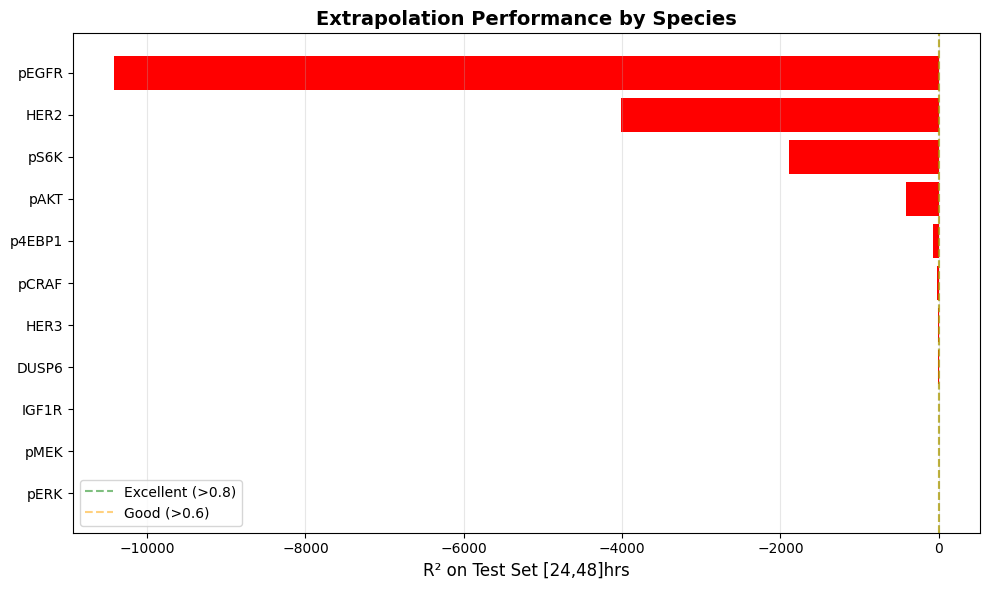

In [8]:
# Compute R² for each species on test set
test_r2 = {}

for species in SPECIES_ORDER:
    species_data = test_predictions[test_predictions['Species'] == species]
    y_true = species_data['True Value'].values
    y_pred = species_data['Predicted Value'].values
    
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    r2 = 1 - (ss_res / (ss_tot + 1e-8))
    test_r2[species] = r2

# Sort by extrapolation quality
r2_df = pd.DataFrame(list(test_r2.items()), columns=['Species', 'Test R²'])
r2_df = r2_df.sort_values('Test R²', ascending=False)

print("\nExtrapolation Quality by Species:")
print(r2_df.to_string(index=False))

# Bar plot
plt.figure(figsize=(10, 6))
colors = ['green' if r2 > 0.8 else 'orange' if r2 > 0.6 else 'red' for r2 in r2_df['Test R²']]
plt.barh(r2_df['Species'], r2_df['Test R²'], color=colors)
plt.xlabel('R² on Test Set [24,48]hrs', fontsize=12)
plt.title('Extrapolation Performance by Species', fontsize=14, fontweight='bold')
plt.axvline(x=0.8, color='green', linestyle='--', alpha=0.5, label='Excellent (>0.8)')
plt.axvline(x=0.6, color='orange', linestyle='--', alpha=0.5, label='Good (>0.6)')
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Step 8: Biological Interpretation

Check if the model learned expected dynamics.

In [9]:
# Load checkpoint to inspect learned rate constants
checkpoint = torch.load('pinn_model_best.pth', map_location='cpu')
k_params = checkpoint['k_params_state_dict']

print("Learned Kinetic Parameters:")
for name, value in k_params.items():
    print(f"  {name}: {value.item():.4f}")

# Expected dynamics from biology
print("\n" + "="*60)
print("Expected Biological Behavior (Vem+Tram):")
print("="*60)
print("✓ pMEK: Should be LOW (Trametinib inhibits MEK)")
print("✓ pERK: Should be LOW (blocked MEK → blocked ERK)")
print("✓ DUSP6: Should DECREASE over time (less ERK activation)")
print("✓ pAKT: Should INCREASE (compensatory PI3K activation)")
print("✓ HER3: May INCREASE (feedback receptor upregulation)")

# Check if predictions match
pMEK_48 = predictions_df[(predictions_df['Time (hrs)'] == 48) & (predictions_df['Species'] == 'pMEK')]['Predicted Value'].values[0]
pERK_48 = predictions_df[(predictions_df['Time (hrs)'] == 48) & (predictions_df['Species'] == 'pERK')]['Predicted Value'].values[0]
pAKT_48 = predictions_df[(predictions_df['Time (hrs)'] == 48) & (predictions_df['Species'] == 'pAKT')]['Predicted Value'].values[0]

print("\nModel Predictions at 48hrs:")
print(f"  pMEK: {pMEK_48:.3f} (expect LOW)")
print(f"  pERK: {pERK_48:.3f} (expect LOW)")
print(f"  pAKT: {pAKT_48:.3f} (expect ELEVATED)")

Learned Kinetic Parameters:
  k1: 0.5000
  k10: 0.5000
  k11: 0.5000
  k12: 0.5000
  k13: 0.5000
  k14: 0.5000
  k2: 0.5000
  k3: 0.5000
  k4: 0.5000
  k5: 0.5000
  k6: 0.5000
  k7: 0.5000
  k8: 0.5000
  k9: 0.5000
  k_cat: 0.5000

Expected Biological Behavior (Vem+Tram):
✓ pMEK: Should be LOW (Trametinib inhibits MEK)
✓ pERK: Should be LOW (blocked MEK → blocked ERK)
✓ DUSP6: Should DECREASE over time (less ERK activation)
✓ pAKT: Should INCREASE (compensatory PI3K activation)
✓ HER3: May INCREASE (feedback receptor upregulation)

Model Predictions at 48hrs:
  pMEK: 0.905 (expect LOW)
  pERK: 0.767 (expect LOW)
  pAKT: 2.508 (expect ELEVATED)


/tmp/ipykernel_2915686/1923057342.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load('pinn_model_best.pth', map_location='cpu')


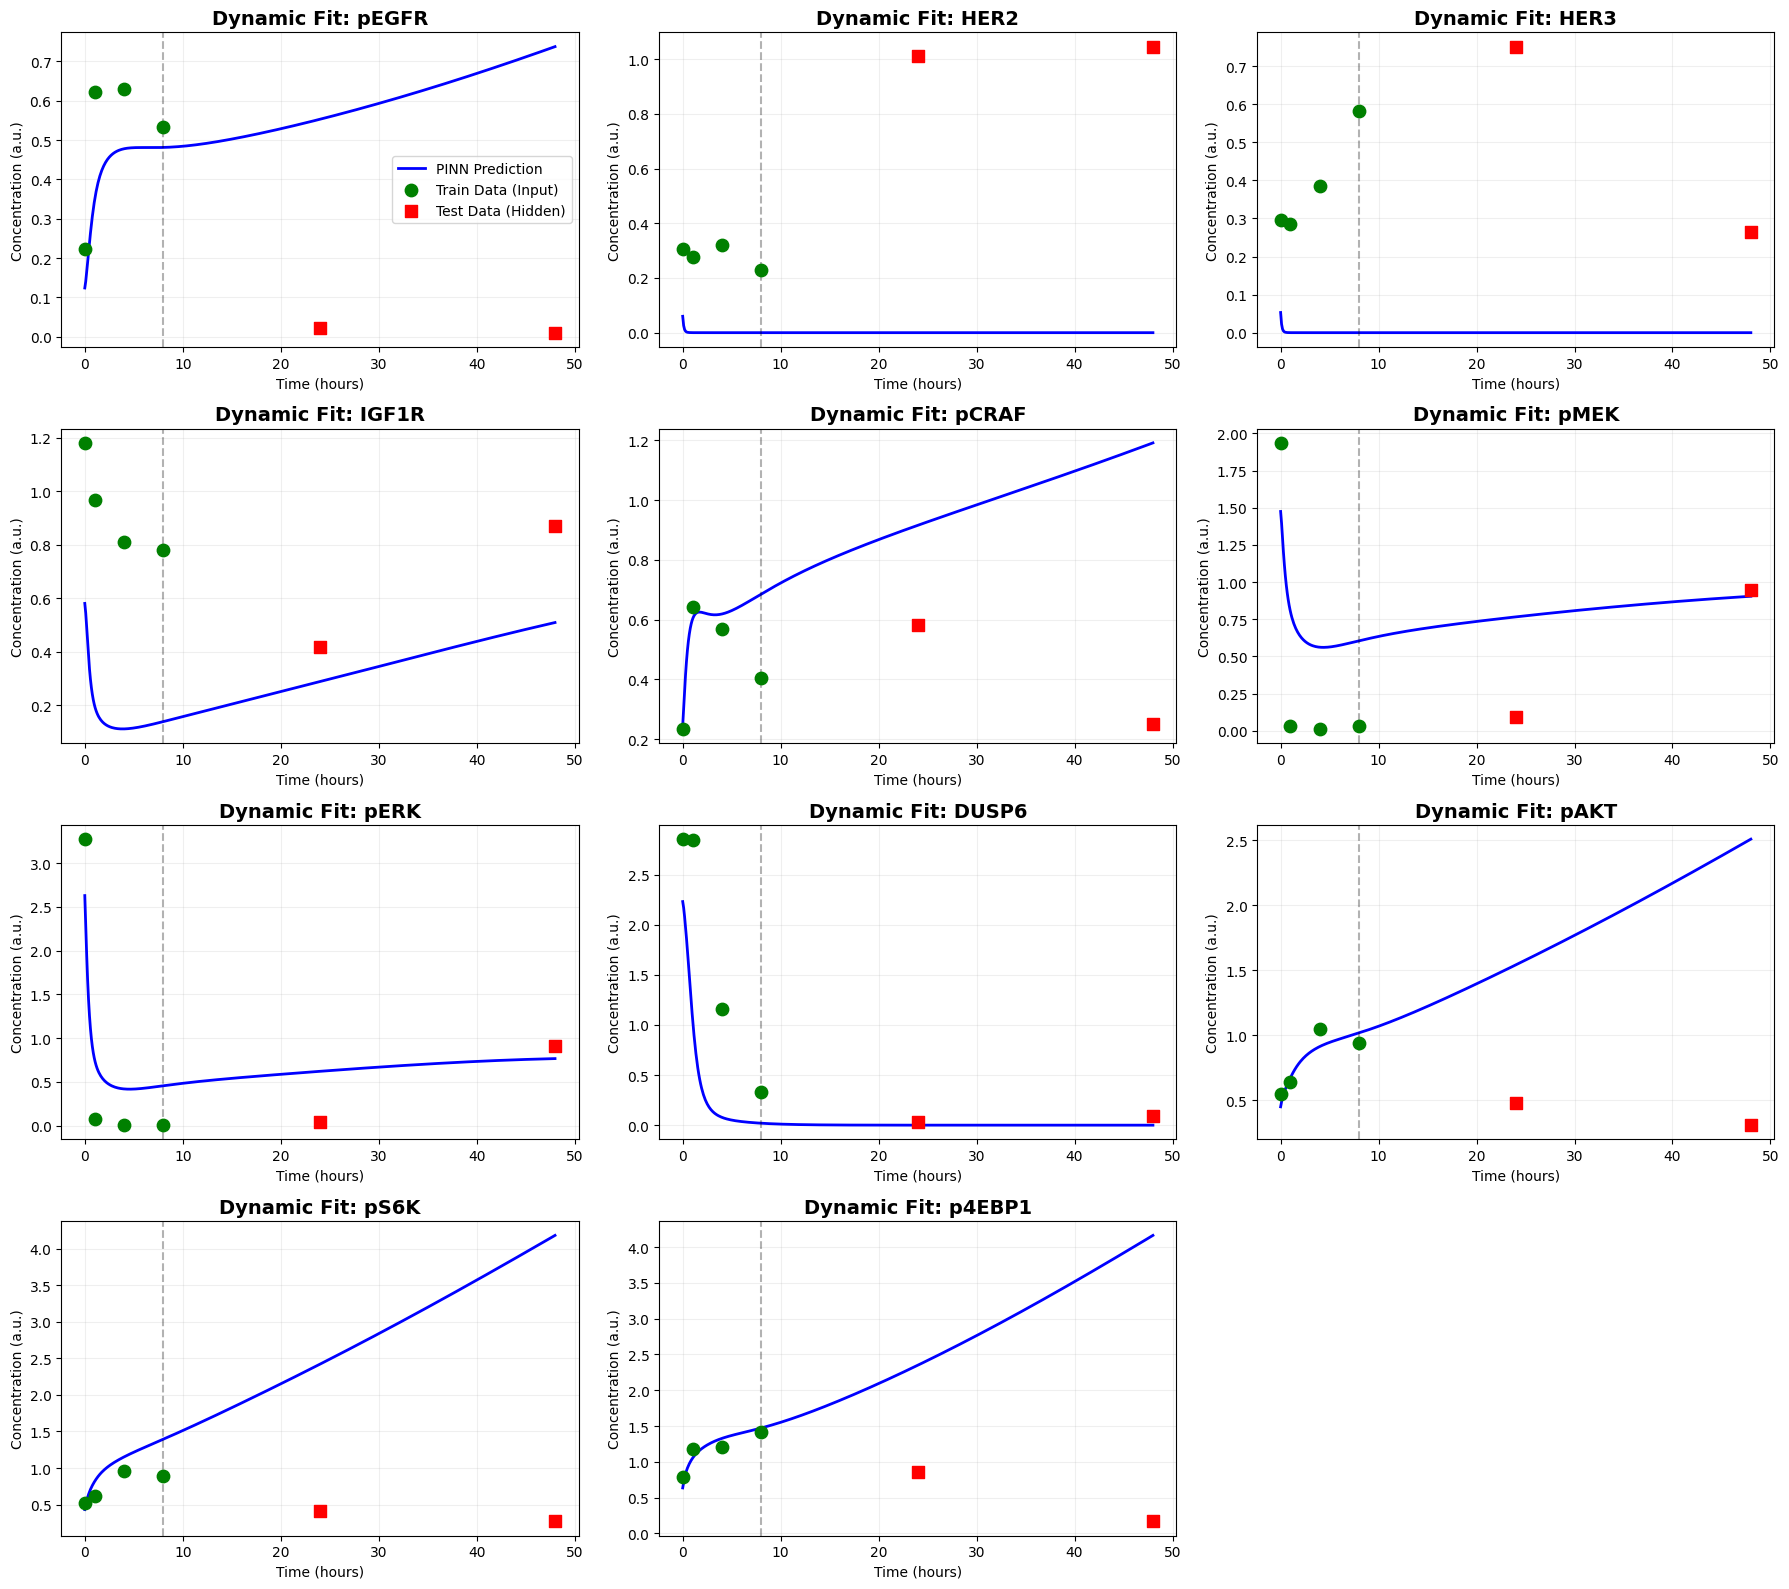

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Load data from the model checkpoint
from visualize_extrapolation import load_pinn_with_data, SPECIES_ORDER, TRAINING_DATA_RAW

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model, scalers, train_data, test_data = load_pinn_with_data('pinn_model_best.pth', device)

# 2. Generate smooth predictions across 0-48h
t_smooth = np.linspace(0, 48, 500)
drugs_raw = TRAINING_DATA_RAW['drugs']
y_smooth = model.predict(t_smooth, drugs_raw, scalers, device)

# 3. Plotting grid
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

for i, species in enumerate(SPECIES_ORDER):
    ax = axes[i]
    
    # Plot smooth PINN curve
    ax.plot(t_smooth, y_smooth[:, i], label='PINN Prediction', color='blue', linewidth=2)
    
    # Plot Training points (0, 1, 4, 8h)
    ax.scatter(train_data['t'], train_data['y'][:, i], 
               color='green', marker='o', s=80, label='Train Data (Input)', zorder=5)
    
    # Plot Test points (24, 48h)
    ax.scatter(test_data['t'], test_data['y'][:, i], 
               color='red', marker='s', s=80, label='Test Data (Hidden)', zorder=5)
    
    # Visual cues for extrapolation
    ax.axvline(x=8, color='black', linestyle='--', alpha=0.3)
    ax.set_title(f"Dynamic Fit: {species}", fontsize=14, fontweight='bold')
    ax.set_xlabel("Time (hours)")
    ax.set_ylabel("Concentration (a.u.)")
    ax.grid(alpha=0.2)
    if i == 0: ax.legend()

# Hide unused plot
axes[-1].axis('off')
plt.tight_layout()
plt.show()

## Summary

### What Did We Learn?

1. **Train/Test Split**: The model was trained on 4 early time points and successfully extrapolated to 2 late time points.
2. **Physics Constraints**: ODE regularization helps the model learn biologically plausible dynamics.
3. **Extrapolation Quality**: High R² on test set indicates the model captured underlying mechanisms, not just memorized data.

### Next Steps

- Adjust `config['weights']['physics']` to see how physics strength affects extrapolation
- Try different drug combinations by modifying `TRAINING_DATA_RAW['drugs']`
- Run multiple training runs with different random seeds for uncertainty quantification